# Efficiency and Fairness in humans

In [19]:
import sys
sys.path.append('../src')

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as patches

from scipy import stats
from collections import defaultdict

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.indices import AlternationIndex
from Classes.cognitive_model_agents import *

In [20]:
path_to_data = PATHS['human_data'] / 'processed_human_data.csv'
data = pd.read_csv(path_to_data)

gm = GetMeasurements(
    data=data, 
    measures=[
        'efficiency', 'bounded_efficiency', 'gini_index', 
        'entropy', 'min_entropy',
    ],
    T=20
)
gm.columns.append('threshold_bin')
df_measures = gm.get_measurements()

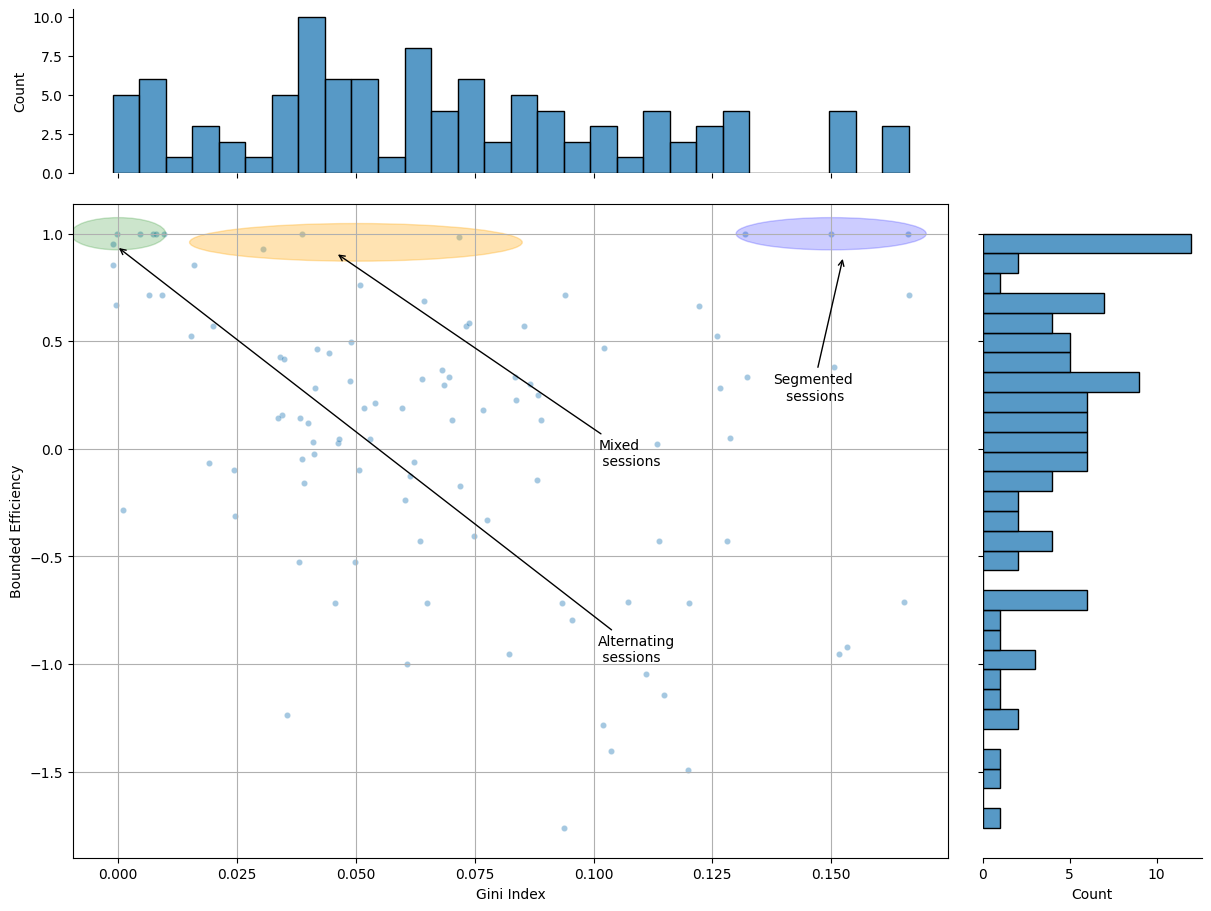

In [21]:
df_jitter = df_measures.copy()
n = df_jitter.shape[0]
sigma = 0.001
df_jitter['gini_index'] = df_jitter['gini_index'] + np.random.normal(0, sigma, n)
df_jitter['bounded_efficiency'] = df_jitter['bounded_efficiency'] + np.random.normal(0, sigma, n)

fig = plt.figure(figsize=(12,9), constrained_layout=True)

# One “slot” in a larger layout could be outer[0]; here we just show the joint block
gs_outer = fig.add_gridspec(1, 1)
gs = gs_outer[0].subgridspec(
    2, 2, height_ratios=[1, 4], width_ratios=[4, 1],
    hspace=0.05, wspace=0.05
)

ax_joint  = fig.add_subplot(gs[1, 0])
ax_marg_x = fig.add_subplot(gs[0, 0], sharex=ax_joint)
ax_marg_y = fig.add_subplot(gs[1, 1], sharey=ax_joint)

# Joint (scatter)
sns.scatterplot(
    x='gini_index', y='bounded_efficiency',
    # style='predicted_class', hue='predicted_class',
    data=df_jitter,
    # hue='treatment', style='num_players',
    alpha=0.4, ax=ax_joint,
    palette='icefire',
    s=20
)
ax_joint.grid()

# Marginals (histograms)
sns.histplot(data=df_jitter, x='gini_index', ax=ax_marg_x, bins=30)
sns.histplot(data=df_jitter, y='bounded_efficiency', ax=ax_marg_y, bins=30)

# Tidy up the marginal axes
ax_marg_x.tick_params(axis="x", labelbottom=False)
ax_marg_x.set_xlabel('')

ax_marg_y.tick_params(axis="y", labelleft=False)
ax_marg_y.set_ylabel('')

sns.despine(ax=ax_marg_x, bottom=True)
sns.despine(ax=ax_marg_y, left=True)

# Labels (now this is a normal Matplotlib figure you control)
ax_joint.set_xlabel("Gini Index")
ax_joint.set_ylabel("Bounded Efficiency")


# Show the alternating groups on the top-left corner
circle = patches.Ellipse(
    (0, 1), width=0.02, height=0.15,
    # transform=ax_joint.transAxes, 
    color='green', alpha=0.2, 
)
ax_joint.add_patch(circle)
# Add an arrow pointing to the cluster
ax_joint.annotate(
    'Alternating\n sessions',
    xy=(0.05, 0.935), xycoords='axes fraction',
    xytext=(0.6, 0.3), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10
)

# Show the mixed groups on the top center
circle = patches.Ellipse(
    (0.05, 0.96), width=0.07, height=0.175,
    # transform=ax.transAxes, 
    color='orange', alpha=0.3, 
)
ax_joint.add_patch(circle)
# Add an arrow pointing to the cluster
ax_joint.annotate(
    'Mixed\n sessions',
    xy=(0.3, 0.925), xycoords='axes fraction',
    xytext=(0.6, 0.6), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10
)

# Show the segmented groups on the top-right corner
circle = patches.Ellipse(
    (0.15, 1), width=0.04, height=0.15, 
    # transform=ax.transAxes, 
    color='blue', alpha=0.2
)
ax_joint.add_patch(circle)
# Add an arrow pointing to the cluster
ax_joint.annotate(
    'Segmented\n   sessions',
    xy=(0.88, 0.92), xycoords='axes fraction',
    xytext=(0.8, 0.7), textcoords='axes fraction',
    arrowprops=dict(facecolor='black', arrowstyle='->'),
    fontsize=10
)

plt.show()

In [22]:
fig.savefig(PATHS['exploratory_figures'] / 'Fig2.png', dpi=300, bbox_inches='tight')

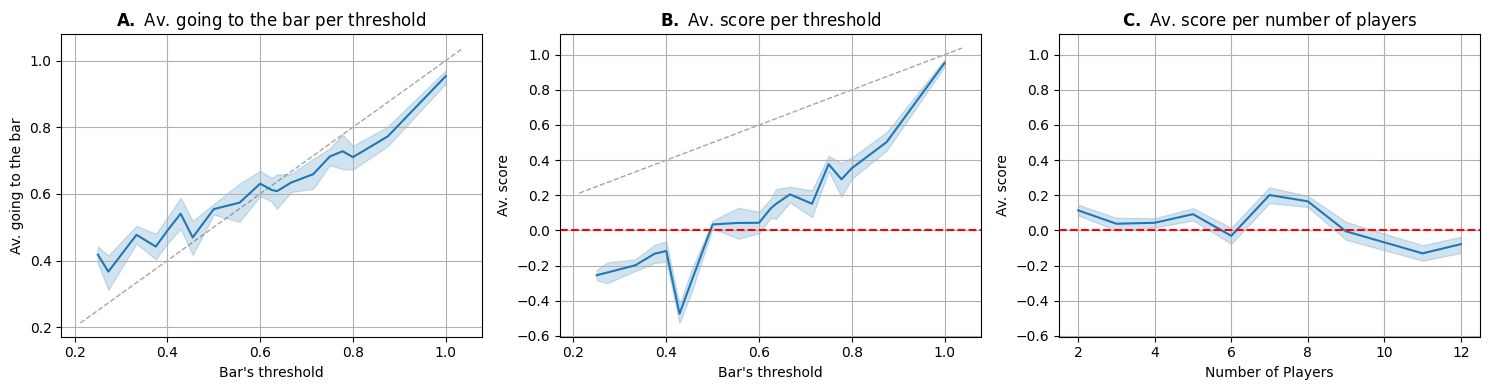

In [23]:
fig, ax = plt.subplots(
    1, 3,
    figsize=(15,4), 
    tight_layout=True
)

sns.lineplot(
    x='threshold', y='decision',
    data=data, ax=ax[0],
)
ax[0].grid()
x0, x1 = ax[0].get_xlim()
y0, y1 = ax[0].get_ylim()
lo, hi = min(x0, y0), max(x1, y1)
ax[0].plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=0)
ax[0].set_xlabel("Bar's threshold")
ax[0].set_ylabel("Av. going to the bar")
ax[0].set_title(r"$\bf{A.}$ Av. going to the bar per threshold")

sns.lineplot(
    x='threshold', y='score',
    data=data, ax=ax[1],
)
ax[1].grid()
ax[1].set_xlabel("Bar's threshold")
ax[1].set_ylabel("Av. score")
ax[1].set_title(r"$\bf{B.}$ Av. score per threshold")
ax[1].plot([lo, hi], [lo, hi], color='gray', linestyle='--', linewidth=1, alpha=0.7, zorder=0)
ax[1].axhline(y=0, color='red', linestyle='--')

sns.lineplot(
    x='num_players', y='score',
    data=data, ax=ax[2],
)
ax[2].grid()
ax[2].set_xlabel("Number of Players")
ax[2].set_ylabel("Av. score")
ax[2].set_title(r"$\bf{C.}$ Av. score per number of players")
y0, y1 = ax[1].get_ylim()
ax[2].set_ylim(y0, y1)
ax[2].axhline(y=0, color='red', linestyle='--')

plt.show()
fig.savefig(PATHS['exploratory_figures'] / 'Fig3.png', dpi=300)

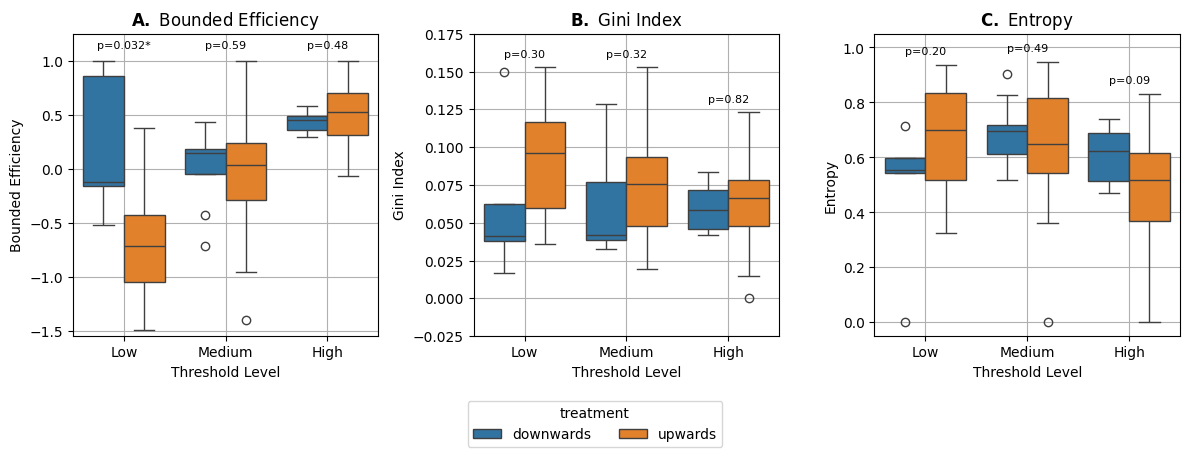

In [30]:
plot_df = df_measures[df_measures["num_players"] >= 3].copy()
bin_order = ["Low", "Medium", "High"]  # adjust if your labels differ

def annotate_binwise_welch(ax, data, x, y, hue, order=None):
    hues = sorted(data[hue].dropna().unique())
    if len(hues) != 2:
        raise ValueError(f"Welch t-test needs exactly 2 {hue} levels; got {hues}")
    h0, h1 = hues[0], hues[1]

    labels = [t.get_text() for t in ax.get_xticklabels()]
    y_lo, y_hi = ax.get_ylim()
    pad = 0.03 * (y_hi - y_lo)
    tops = []

    for i, xv in enumerate(labels):
        sub = data[data[x].astype(str) == str(xv)]
        a = sub.loc[sub[hue] == h0, y].dropna().to_numpy()
        b = sub.loc[sub[hue] == h1, y].dropna().to_numpy()
        if len(a) < 2 or len(b) < 2:
            continue
        _, p = stats.ttest_ind(a, b, equal_var=False, nan_policy="omit")
        if p < 1e-4:
            ps = "p<1e-4"
        elif p < 0.001:
            ps = "p<0.001"
        elif p < 0.05:
            ps = f"p={p:.3f}*"
        else:
            ps = f"p={p:.2f}"
        ymax = float(sub[y].max())
        tops.append(ymax + pad)
        ax.text(i, ymax + pad, ps, ha="center", va="bottom", fontsize=8)

    if tops:
        ax.set_ylim(y_lo, max(y_hi, max(tops) + pad))


fig, ax = plt.subplots(1, 3, figsize=(12, 4), tight_layout=True)

sns.boxplot(
    data=plot_df,
    x="threshold_bin",
    y="bounded_efficiency",
    hue="treatment",
    order=bin_order,
    ax=ax[0],
)
annotate_binwise_welch(ax[0], plot_df, "threshold_bin", "bounded_efficiency", "treatment")
ax[0].set_ylim(-1.55, 1.25)
ax[0].set_title(r"$\bf{A.}$ Bounded Efficiency")
ax[0].set_xlabel("Threshold Level")
ax[0].set_ylabel("Bounded Efficiency")

sns.boxplot(
    data=plot_df,
    x="threshold_bin",
    y="gini_index",
    hue="treatment",
    order=bin_order,
    ax=ax[1],
)
annotate_binwise_welch(ax[1], plot_df, "threshold_bin", "gini_index", "treatment")
ax[1].set_ylim(-0.025, 0.175)
ax[1].set_title(r"$\bf{B.}$ Gini Index")
ax[1].set_xlabel("Threshold Level")
ax[1].set_ylabel("Gini Index")

sns.boxplot(
    data=plot_df,
    x="threshold_bin",
    y="entropy",
    hue="treatment",
    order=bin_order,
    ax=ax[2],
)
annotate_binwise_welch(ax[2], plot_df, "threshold_bin", "entropy", "treatment")
ax[2].set_ylim(-0.05, 1.05)
ax[2].set_title(r"$\bf{C.}$ Entropy")
ax[2].set_xlabel("Threshold Level")
ax[2].set_ylabel("Entropy")

# One legend for the figure (optional)
handles, labels = ax[0].get_legend_handles_labels()
ax[0].legend_.remove()
ax[1].legend_.remove()
ax[2].legend_.remove()
fig.legend(handles, labels, title="treatment", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 0.001))

for ax_ in ax:
    ax_.grid()

fig.tight_layout()
plt.show()

In [31]:
fig.savefig(PATHS['exploratory_figures'] / 'Fig4.png', dpi=300, bbox_inches='tight')